<a href="https://colab.research.google.com/github/Abdullahghazanfar/Brain-Tumor-MRI-Classifier-Using-CNN-Project/blob/main/brain_tumor_MRI_project_by_using_(YOLOv8)_Abdullah_Ghazanfar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
mkdir -p ~/.kaggle && echo KGAT_0dcbde55e0789f0c15a4d431ae0eaa53 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:03<00:00, 41.6MB/s]



In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
# data catagories of images
import os

train_dir = './Training'
test_dir = './Testing'

# List the folders inside the Training directory
classes = os.listdir(train_dir)
print(f"Found {len(classes)} tumor categories:")
for category in classes:
    # Count how many images are in each category folder
    num_images = len(os.listdir(os.path.join(train_dir, category)))
    print(f"- {category}: {num_images} images")

Found 4 tumor categories:
- meningioma: 1400 images
- notumor: 1400 images
- pituitary: 1400 images
- glioma: 1400 images


In [ ]:
import os
import shutil

# Create a parent directory for the dataset
dataset_dir = './brain_tumor_dataset'
os.makedirs(dataset_dir, exist_ok=True)

# Move and rename the Training and Testing folders
if os.path.exists('./Training'):
    shutil.move('./Training', os.path.join(dataset_dir, 'train'))
if os.path.exists('./Testing'):
    shutil.move('./Testing', os.path.join(dataset_dir, 'val'))

print("Dataset restructured successfully for YOLOv8 classification!")

Dataset restructured successfully for YOLOv8 classification!


In [ ]:
!pip uninstall -y torch torchvision torchaudio nvidia-nccl-cu12 nvidia-nccl-cu13
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install ultralytics

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Found existing installation: nvidia-nccl-cu12 2.28.9
Uninstalling nvidia-nccl-cu12-2.28.9:
  Successfully uninstalled nvidia-nccl-cu12-2.28.9
Found existing installation: nvidia-nccl-cu13 2.31.2
Uninstalling nvidia-nccl-cu13-2.31.2:
  Successfully uninstalled nvidia-nccl-cu13-2.31.2
Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.3/341.3 kB 33.5 MB/s eta 0:00:00
   ━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.7 MB/s eta 0:00:00


In [ ]:
import os

os.makedirs('/content/brain_tumor_dataset', exist_ok=True)

if os.path.exists('/content/Training'):
    os.rename('/content/Training', '/content/brain_tumor_dataset/train')
if os.path.exists('/content/Testing'):
    os.rename('/content/Testing', '/content/brain_tumor_dataset/val')

print("✅ Dataset ready.")

✅ Dataset ready.


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load the model
model = YOLO('yolov8n-cls.pt')

# Start training on the CPU
results = model.train(
    data='/content/brain_tumor_dataset',
    epochs=20,
    imgsz=224,
    batch=32,
    device='cpu',
    project='BrainTumorClassifier',
    name='run1_cpu'
)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.13.0+cpu CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain_tumor_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1_cpu-2, nbs=64, nms=F

✅ Displaying training curves from: runs/classify/BrainTumorClassifier/run1_cpu-2/results.png


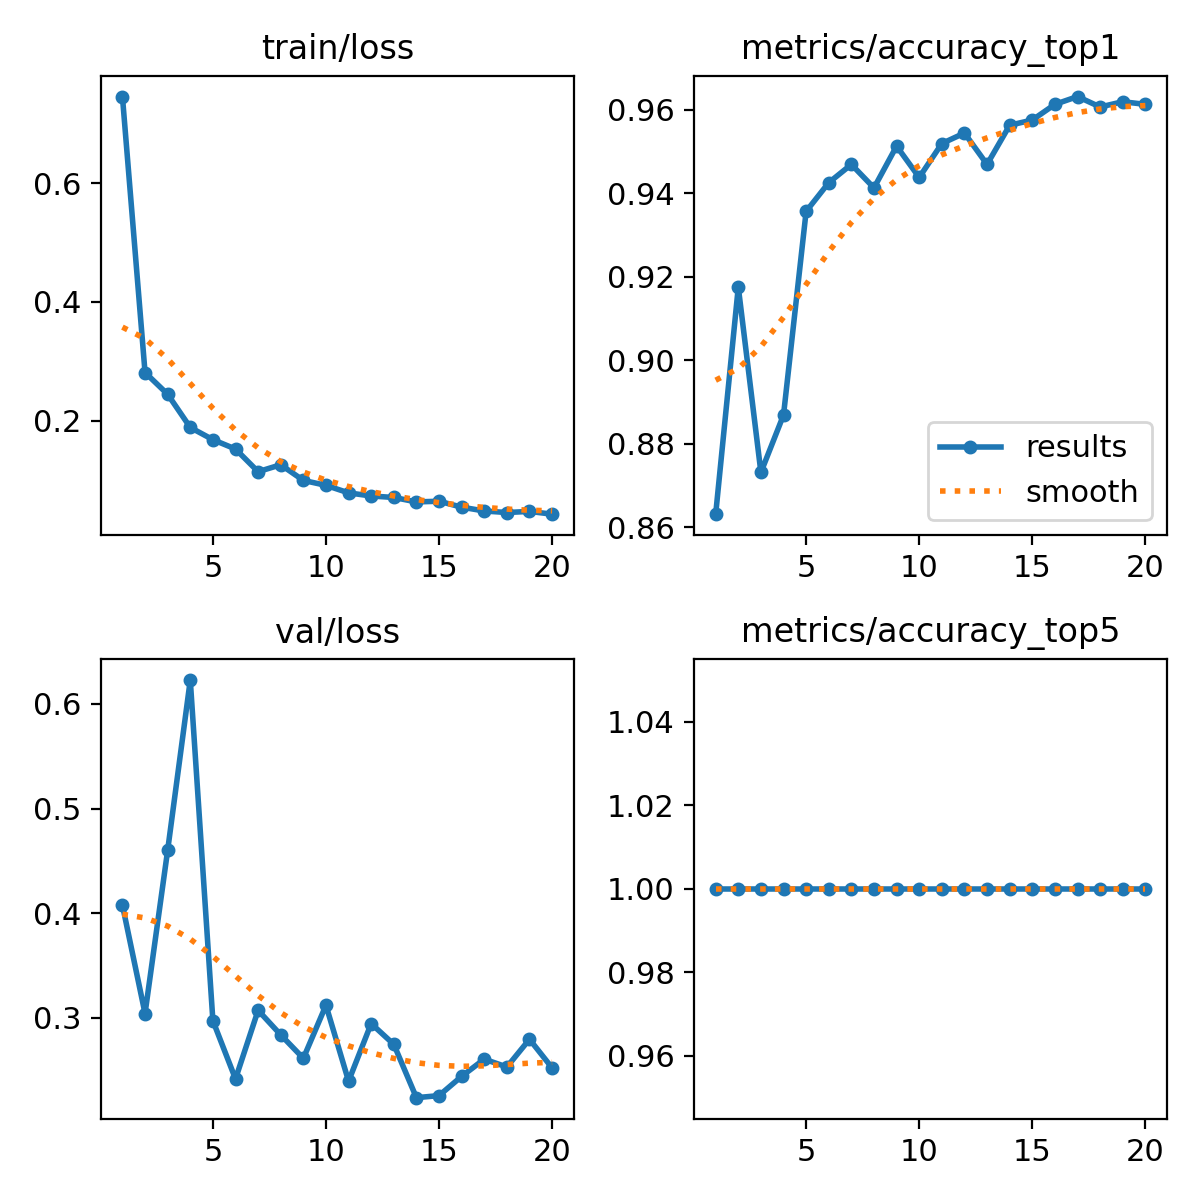


✅ Displaying confusion matrix from: runs/classify/BrainTumorClassifier/run1_cpu-2/confusion_matrix.png


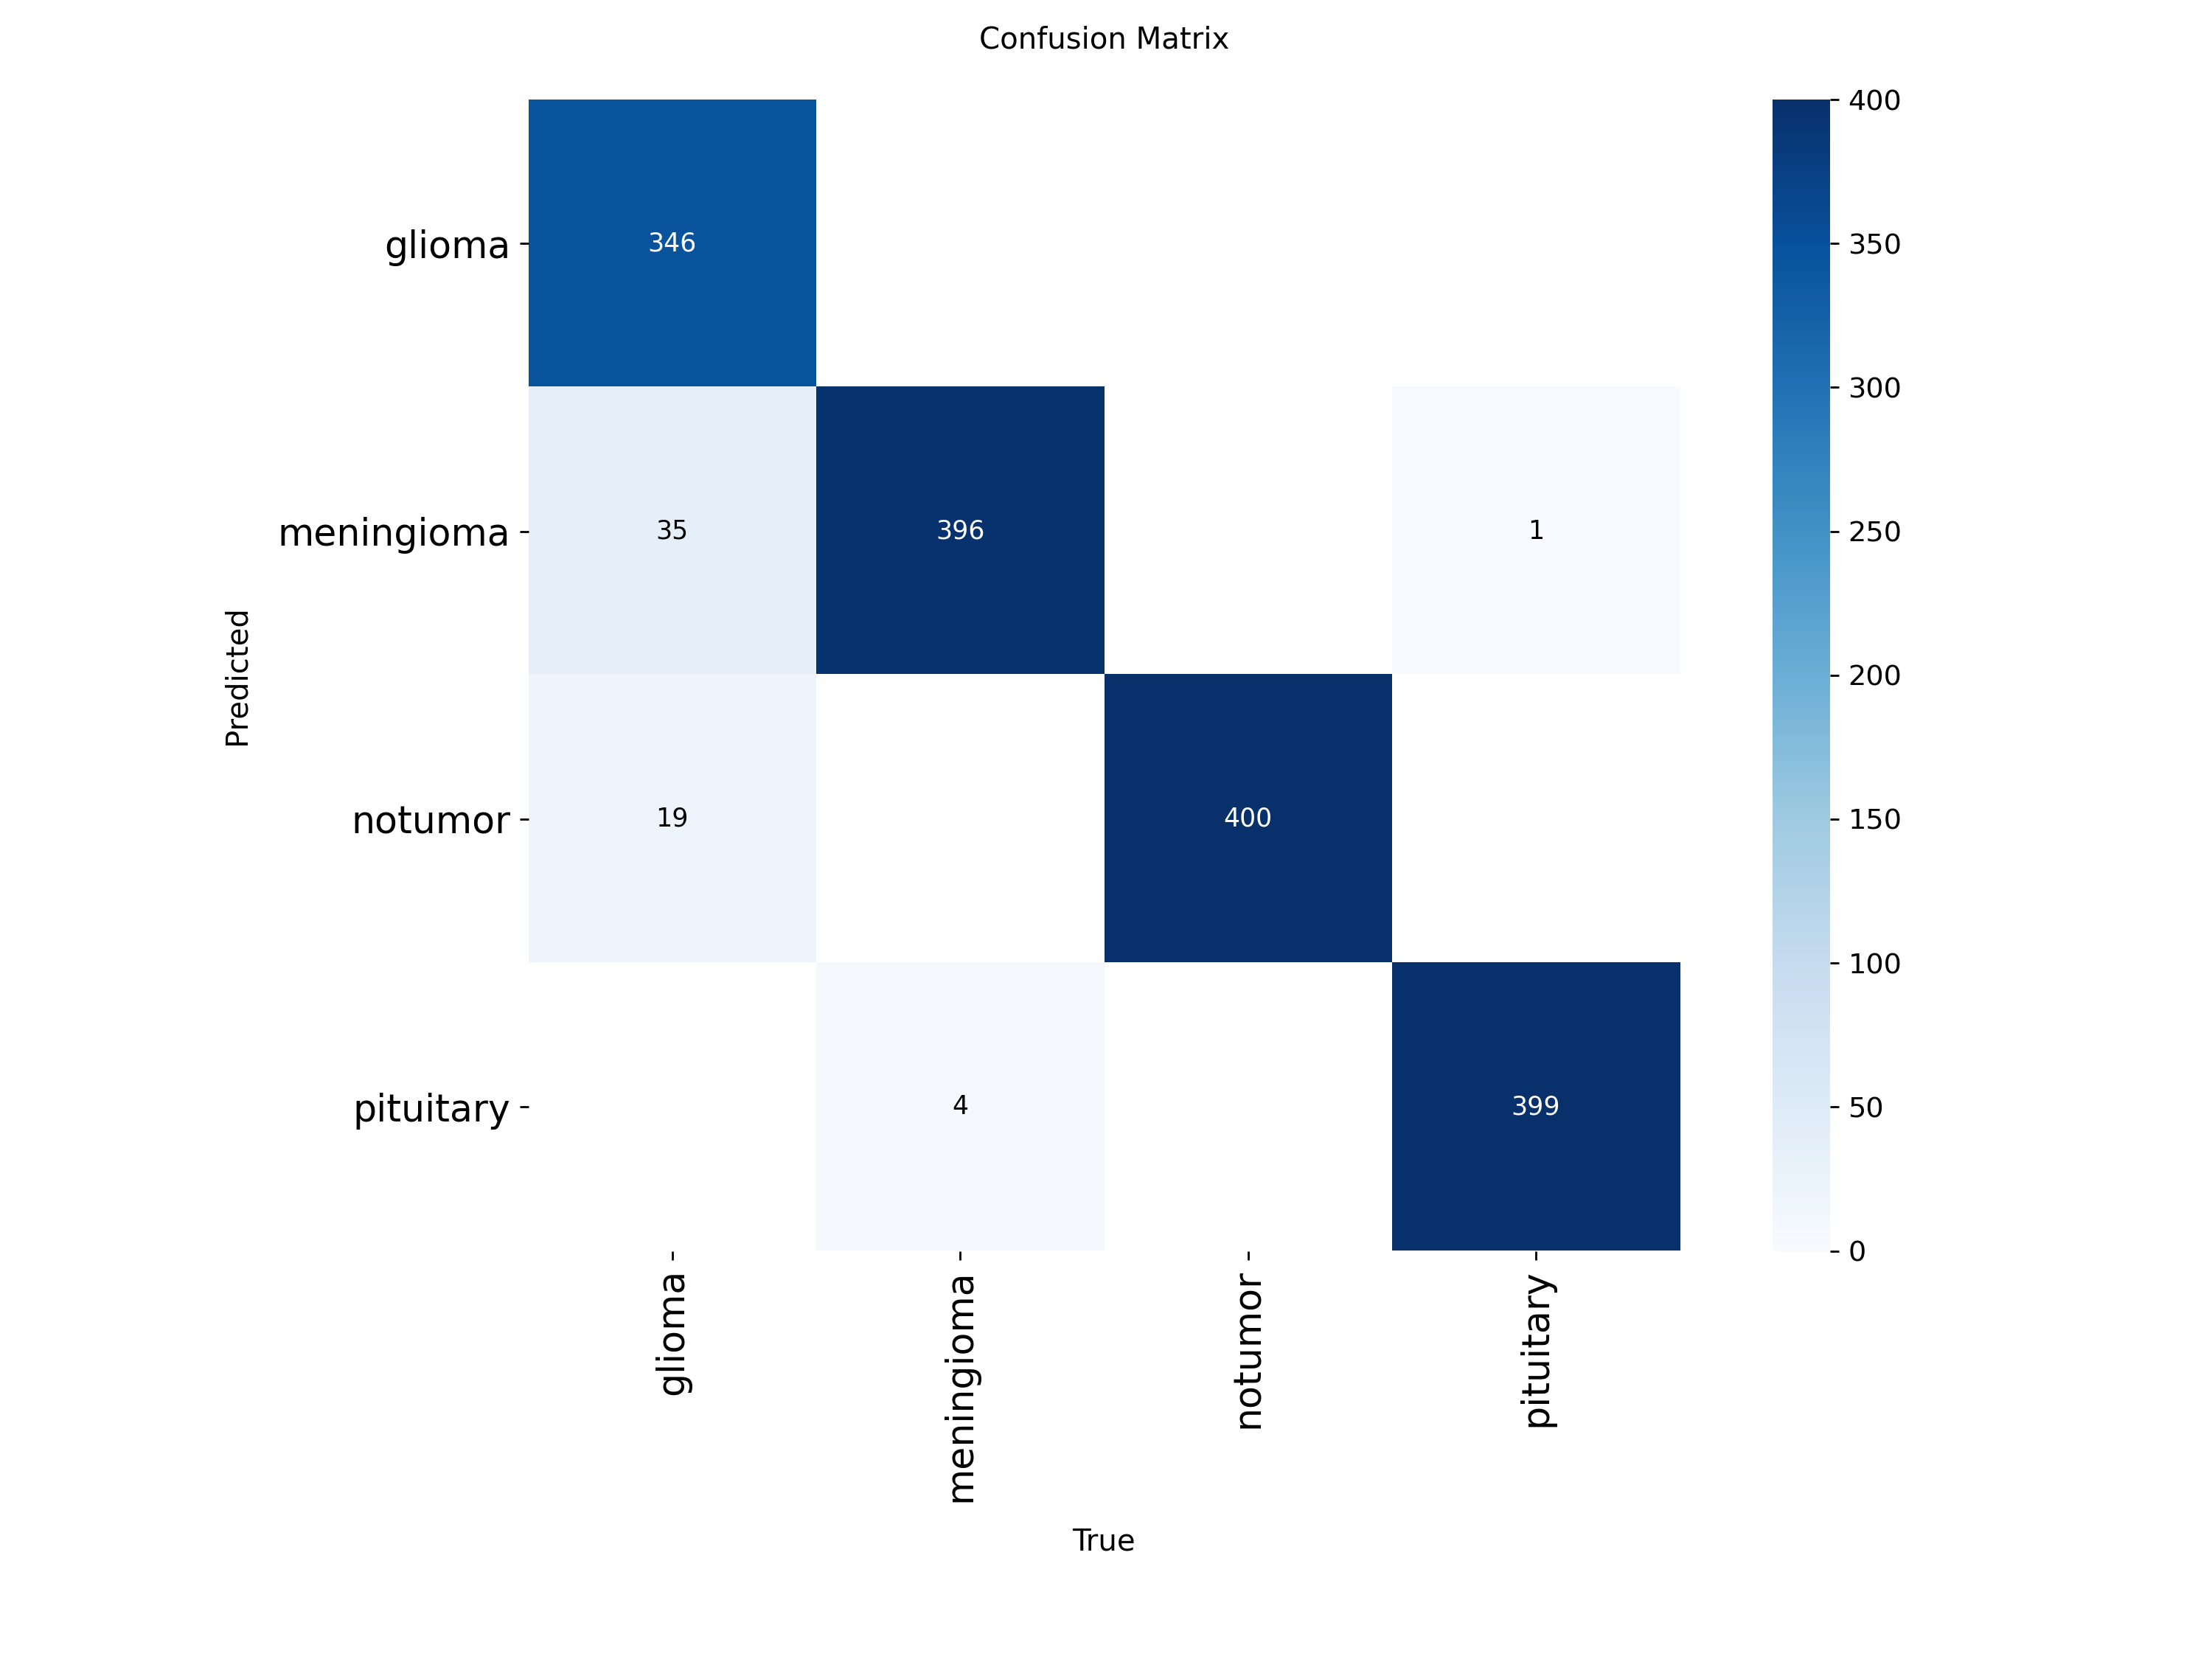

In [ ]:
import glob
import os
from IPython.display import Image, display

# Search recursively for results.png and confusion_matrix.png
results_files = glob.glob('**/results.png', recursive=True)
cm_files = glob.glob('**/confusion_matrix.png', recursive=True)

if results_files:
    # Use the most recently created results file
    latest_results = results_files[-1]
    print(f"✅ Displaying training curves from: {latest_results}")
    display(Image(filename=latest_results))
else:
    print("❌ 'results.png' was not found in the current directory.")
    print("Available folders in workspace:", [d for d in os.listdir('.') if os.path.isdir(d)])

if cm_files:
    latest_cm = cm_files[-1]
    print(f"\n✅ Displaying confusion matrix from: {latest_cm}")
    display(Image(filename=latest_cm))

In [ ]:
!pip install gradio

In [ ]:
import glob
import gradio as gr
from ultralytics import YOLO

# 1. Dynamically locate your trained model weights
weight_files = sorted(glob.glob('**/best.pt', recursive=True))
if not weight_files:
    print("❌ Could not find best.pt. Make sure your model finished training.")
else:
    print(f"✅ Loading model from: {weight_files[-1]}")
    model = YOLO(weight_files[-1])

    # 2. Define the prediction logic
    def predict_mri(image):
        # Run the image through the YOLOv8 model
        results = model.predict(source=image)
        probs = results[0].probs

        # Extract class names and their confidence scores
        class_names = model.names
        confidence_scores = probs.data.tolist()

        # Create a dictionary for Gradio (e.g., {"glioma": 0.85, "notumor": 0.02})
        predictions = {class_names[i]: confidence_scores[i] for i in range(len(class_names))}
        return predictions

    # 3. Create the web interface layout
    interface = gr.Interface(
        fn=predict_mri,
        inputs=gr.Image(type="numpy", label="Upload Brain MRI Scan"),
        outputs=gr.Label(num_top_classes=4, label="Diagnosis Probabilities"),
        title="🧠 YOLOv8 Brain Tumor Classifier",
        description="Upload an MRI scan to instantly classify it as Glioma, Meningioma, Pituitary, or Healthy (Notumor)."
    )

    # 4. Launch the app with a public URL
    interface.launch(share=True)

✅ Loading model from: runs/classify/BrainTumorClassifier/run1_cpu-2/weights/best.pt
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://12d8534111125603f8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import drive
import shutil
import os
import glob
from ultralytics import YOLO

# 1. Connect Google Drive
drive.mount('/content/drive')
drive_folder = '/content/drive/MyDrive/Brain_Tumor_Project'
os.makedirs(drive_folder, exist_ok=True)

# 2. Locate your trained weights
weight_files = sorted(glob.glob('**/best.pt', recursive=True))
best_weights = weight_files[-1]
model = YOLO(best_weights)

# 3. Export to ONNX format
print("Exporting model to ONNX format...")
onnx_path = model.export(format='onnx')

# 4. Save both formats to your Drive
shutil.copy(best_weights, os.path.join(drive_folder, 'yolov8_brain_tumor.pt'))
shutil.copy(onnx_path, os.path.join(drive_folder, 'yolov8_brain_tumor.onnx'))

print(f"✅ Models successfully backed up to: {drive_folder}")

Mounted at /content/drive
Exporting model to ONNX format...
Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.13.0+cpu CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 0.4 GFLOPs

PyTorch: starting from 'runs/classify/BrainTumorClassifier/run1_cpu-2/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 4) (2.8 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 300ms
Prepared 4 packages in 2.11s
Installed 4 packages in 419ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take eff